In [1]:
import base64
import os
import sys

from dotenv import load_dotenv
from openai import OpenAI

In [2]:
load_dotenv()
if not os.getenv("DASHSCOPE_API_KEY"):
    sys.exit("Set DASHSCOPE_API_KEY via secrun (see SECRETS.md) and try again.")

In [3]:
client = OpenAI(
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
    api_key=os.getenv("DASHSCOPE_API_KEY")
)

In [5]:
path = r"D:\newgame\openai-api-deep-dive\examples\test1.png"

In [6]:
ext = os.path.splitext(path)[1].lower().lstrip(".") or "png"

In [8]:
mime = {"jpg": "jpeg"}.get(ext, ext)  # .jpg -> image/jpeg

In [10]:
with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("ascii")

In [13]:
print(type(b64))

<class 'str'>


In [14]:
image_part = {"type": "image_url", "image_url": {"url": f"data:image/{mime};base64,{b64}"}}

{'type': 'image_url',
 'image_url': {'url': ''}}
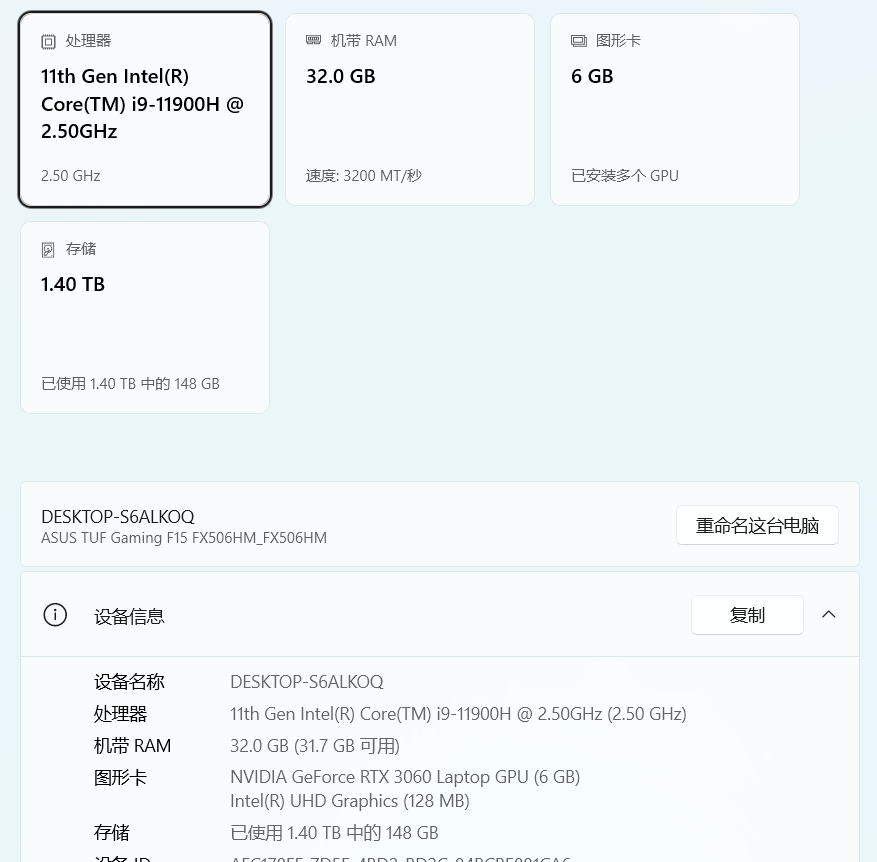

In [15]:
image_part

{'url': '',
 'detail': 'auto'}
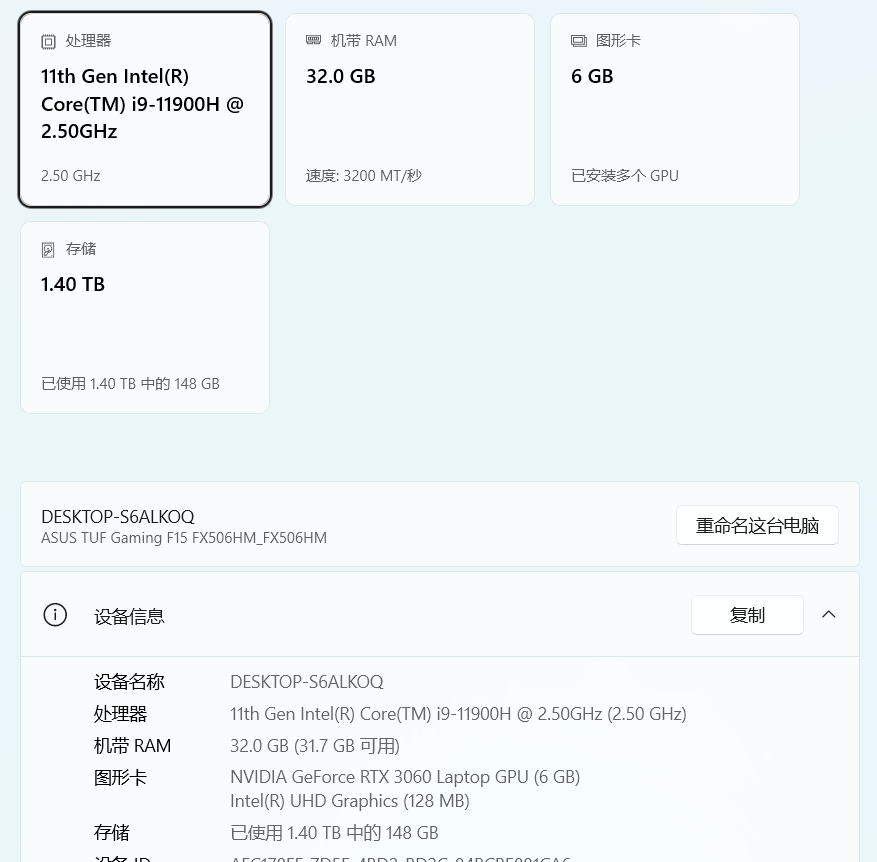

In [17]:
{**image_part["image_url"], "detail": "auto"}

{'type': 'image_url',
 'image_url': {'url': '',
  'detail': 'auto'}}
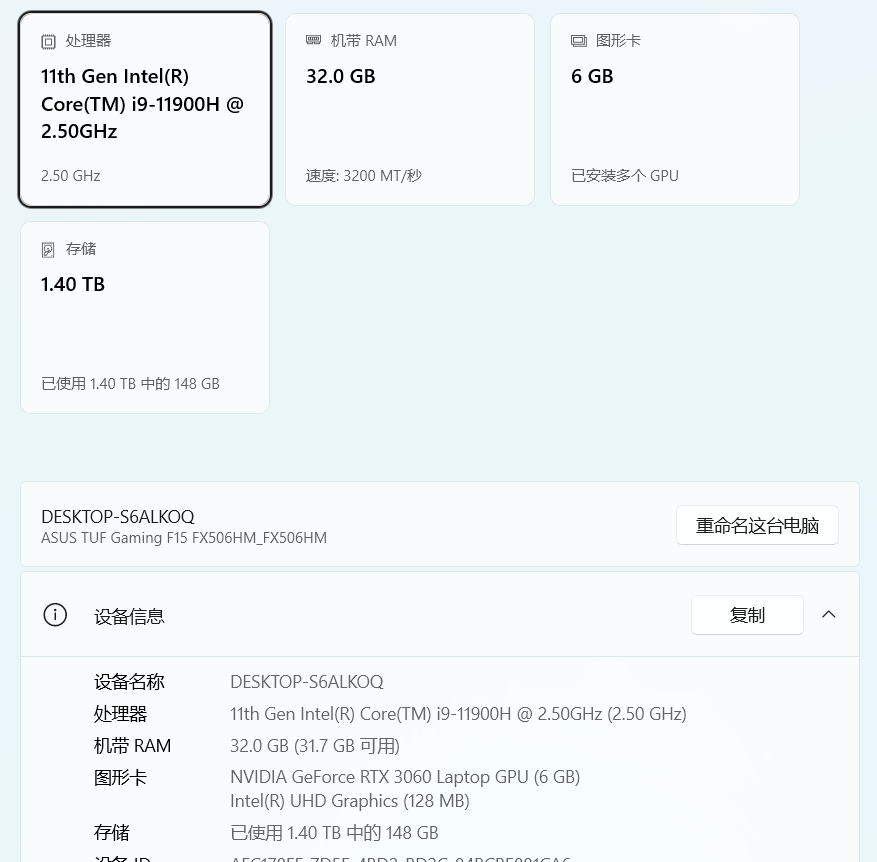

In [18]:
{**image_part, "image_url": {**image_part["image_url"], "detail": "auto"}}

In [19]:
print(type({**image_part, "image_url": {**image_part["image_url"], "detail": "auto"}}))

<class 'dict'>


In [20]:
print(type({**image_part["image_url"], "detail": "auto"}))

<class 'dict'>


In [21]:
response = client.chat.completions.create(
    model="qwen3.7-plus",  # the -mini models are multimodal too
    messages=[
        {  # type: ignore[arg-type]
            "role": "user",
            "content": [
                {"type": "text", "text": "Describe this image in two sentences. What stands out?"},
                {**image_part, "image_url": {**image_part["image_url"], "detail": "auto"}},
            ],
        }
    ],
)

In [22]:
print(response.choices[0].message.content)
assert response.usage is not None
print(f"\n[tokens: prompt: {response.usage.prompt_tokens}, "
      f"completion: {response.usage.completion_tokens}]")
print("Notice the prompt tokens: the image itself is most of them. Bigger image = more tokens.")

This image displays the system specifications for an ASUS TUF Gaming F15 laptop, presenting hardware details like processor speed, RAM, and storage capacity in a clean, card-based interface. What stands out is the high-performance configuration, specifically the powerful 11th Gen Intel Core i9 processor paired with 32 GB of RAM and an NVIDIA GeForce RTX 3060 graphics card.

[tokens: prompt: 752, completion: 690]
Notice the prompt tokens: the image itself is most of them. Bigger image = more tokens.
